# Exploratory Analysis: Cambodia General Job Market

Use this notebook after running `uv run python main.py --skip-database`. It reads the cleaned CSV files and creates quick checks before building the Power BI dashboard.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
jobs_path = PROJECT_ROOT / 'data' / 'cleaned' / 'cleaned_jobs.csv'
skills_path = PROJECT_ROOT / 'data' / 'cleaned' / 'job_skills.csv'

jobs = pd.read_csv(jobs_path)
job_skills = pd.read_csv(skills_path)

jobs.head()

,job_id,source_name,job_title,job_category,company_name,location,salary,salary_min,salary_max,salary_avg,salary_currency,employment_type,experience_level,job_description,skills,date_posted,source_url,scraped_at
0,SAMPLE-BONGTHOM-01419,BongThom,Junior Finance Analyst Representative - Field ...,Accounting / Finance,CARE Cambodia,Banteay Meanchey,"$710 - $1,420 per month",710.0,1420.0,1065.0,USD,Full-time,Mid level,Work in accounting / finance for a Cambodia-ba...,Excel; Accounting; Finance; Leadership; Report...,2026-05-08,https://sample.local/bongthom/cambodia-job-01419,2026-06-01T03:26:39Z
1,SAMPLE-BONGTHOM-01809,BongThom,Provincial Finance Analyst - Quality,Accounting / Finance,CARE Cambodia,Banteay Meanchey,"$620 - $1,240 per month",620.0,1240.0,930.0,USD,Full-time,Mid level,Work in accounting / finance for a Cambodia-ba...,Excel; Accounting; Finance; Leadership; Report...,2026-05-23,https://sample.local/bongthom/cambodia-job-01809,2026-06-01T03:26:39Z
2,SAMPLE-BONGTHOM-01029,BongThom,Provincial Finance Analyst Coordinator - Custo...,Accounting / Finance,CARE Cambodia,Banteay Meanchey,"$590 - $1,180 per month",590.0,1180.0,885.0,USD,Full-time,Mid level,Work in accounting / finance for a Cambodia-ba...,Excel; Accounting; Finance; Leadership; Report...,2026-04-23,https://sample.local/bongthom/cambodia-job-01029,2026-06-01T03:26:39Z
3,SAMPLE-BONGTHOM-01006,BongThom,Corporate Accountant Officer - Customer Experi...,Accounting / Finance,Cambrew,Battambang,$400 - $760 per month,400.0,760.0,580.0,USD,Full-time,Mid level,Work in accounting / finance for a Cambodia-ba...,Microsoft Office; Excel; Accounting; Finance; ...,2026-05-16,https://sample.local/bongthom/cambodia-job-01006,2026-06-01T03:26:39Z
4,SAMPLE-BONGTHOM-01786,BongThom,Corporate Accountant Representative - Service ...,Accounting / Finance,Cambrew,Battambang,$430 - $810 per month,430.0,810.0,620.0,USD,Full-time,Mid level,Work in accounting / finance for a Cambodia-ba...,Microsoft Office; Excel; Accounting; Finance; ...,2026-05-01,https://sample.local/bongthom/cambodia-job-01786,2026-06-01T03:26:39Z


In [2]:
jobs.info()

<class 'pandas.DataFrame'>
RangeIndex: 11874 entries, 0 to 11873
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   job_id            11874 non-null  str    
 1   source_name       11874 non-null  str    
 2   job_title         11874 non-null  str    
 3   job_category      11874 non-null  str    
 4   company_name      11874 non-null  str    
 5   location          11874 non-null  str    
 6   salary            11785 non-null  str    
 7   salary_min        11774 non-null  float64
 8   salary_max        11774 non-null  float64
 9   salary_avg        11774 non-null  float64
 10  salary_currency   11874 non-null  str    
 11  employment_type   11874 non-null  str    
 12  experience_level  11874 non-null  str    
 13  job_description   11874 non-null  str    
 14  skills            11811 non-null  str    
 15  date_posted       11788 non-null  str    
 16  source_url        11874 non-null  str    
 17  scra

In [3]:
overview = {
    'total_jobs': jobs['job_id'].nunique(),
    'total_sources': jobs['source_name'].nunique(),
    'total_companies': jobs['company_name'].nunique(),
    'total_locations': jobs['location'].nunique(),
    'total_categories': jobs['job_category'].nunique(),
    'average_salary_usd': jobs['salary_avg'].mean(),
}
overview

{'total_jobs': 11874,
 'total_sources': 13,
 'total_companies': 108,
 'total_locations': 70,
 'total_categories': 19,
 'average_salary_usd': np.float64(745.3568455919823)}

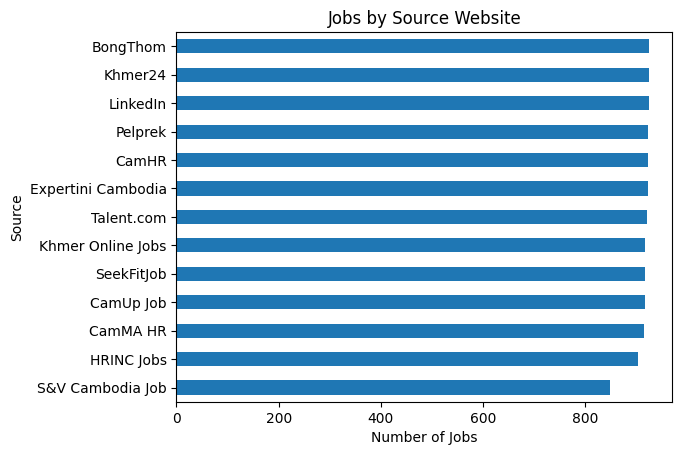

In [4]:
jobs['source_name'].value_counts().plot(kind='barh', title='Jobs by Source Website')
plt.xlabel('Number of Jobs')
plt.ylabel('Source')
plt.gca().invert_yaxis()
plt.show()

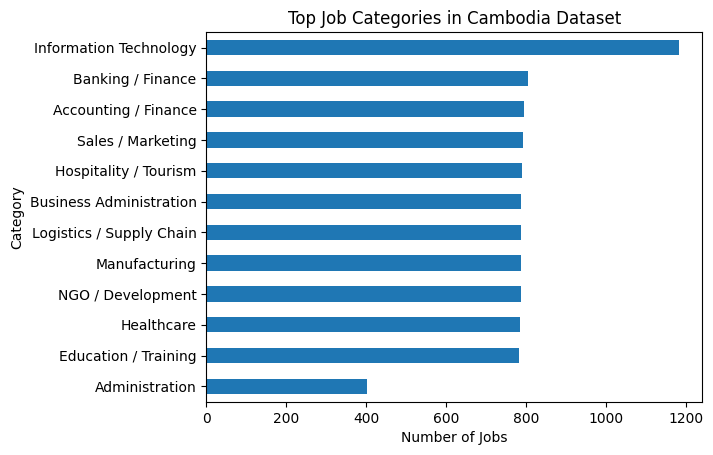

In [5]:
top_categories = jobs['job_category'].value_counts().head(12)
top_categories.plot(kind='barh', title='Top Job Categories in Cambodia Dataset')
plt.xlabel('Number of Jobs')
plt.ylabel('Category')
plt.gca().invert_yaxis()
plt.show()

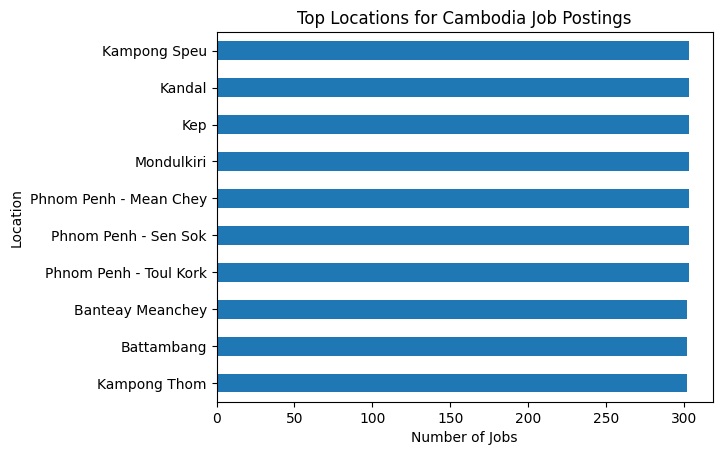

In [6]:
top_locations = jobs['location'].value_counts().head(10)
top_locations.plot(kind='barh', title='Top Locations for Cambodia Job Postings')
plt.xlabel('Number of Jobs')
plt.ylabel('Location')
plt.gca().invert_yaxis()
plt.show()

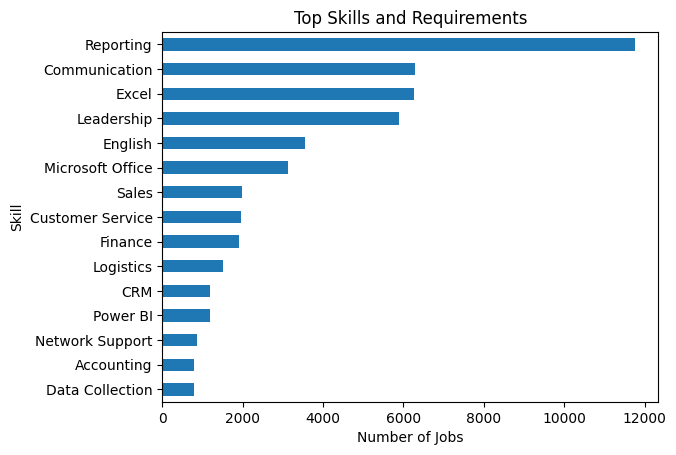

In [7]:
top_skills = job_skills['skill'].value_counts().head(15)
top_skills.plot(kind='barh', title='Top Skills and Requirements')
plt.xlabel('Number of Jobs')
plt.ylabel('Skill')
plt.gca().invert_yaxis()
plt.show()

In [8]:
salary_by_category = jobs.groupby('job_category')['salary_avg'].mean().sort_values(ascending=False)
salary_by_category

job_category
Business Administration     1096.571247
Information Technology      1058.184902
NGO / Development           1043.989835
Operations                   847.426121
Education / Training         792.503201
Accounting / Finance         790.167726
Hospitality / Tourism        767.606599
Other                        704.125000
Legal / Compliance           694.690840
Procurement                  688.311688
Creative / Design            650.178117
Healthcare                   650.114504
Logistics / Supply Chain     617.419847
Human Resources              594.847328
Manufacturing                593.991730
Sales / Marketing            578.547315
Banking / Finance            559.516539
Customer Service             377.709924
Administration               356.328283
Name: salary_avg, dtype: float64